In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
#load the dataset into a data frame
from sklearn.datasets import load_iris

In [20]:
iris = load_iris()
len(iris)

8

In [6]:
#this has pure classifications based on numbre 
iris["target"]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [11]:
#make the data set 
df = sns.load_dataset("iris")

In [12]:
#split the independent and dependent data
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [21]:
#split the dependent and independent featyres
x = df.iloc[:,:-1] #get every thing execpt the target
y = iris["target"] #get the numbered target
len(y)

150

In [22]:
#make the train test split of the data
from sklearn.model_selection import train_test_split as tts 
x_train,x_test,y_train,y_test = tts(x,y,random_state= 39 , test_size= 0.3)

In [49]:
#get the model
from sklearn.tree import DecisionTreeClassifier
#apply post pruning on the decision tree
model = DecisionTreeClassifier(criterion='entropy') 

In [50]:
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

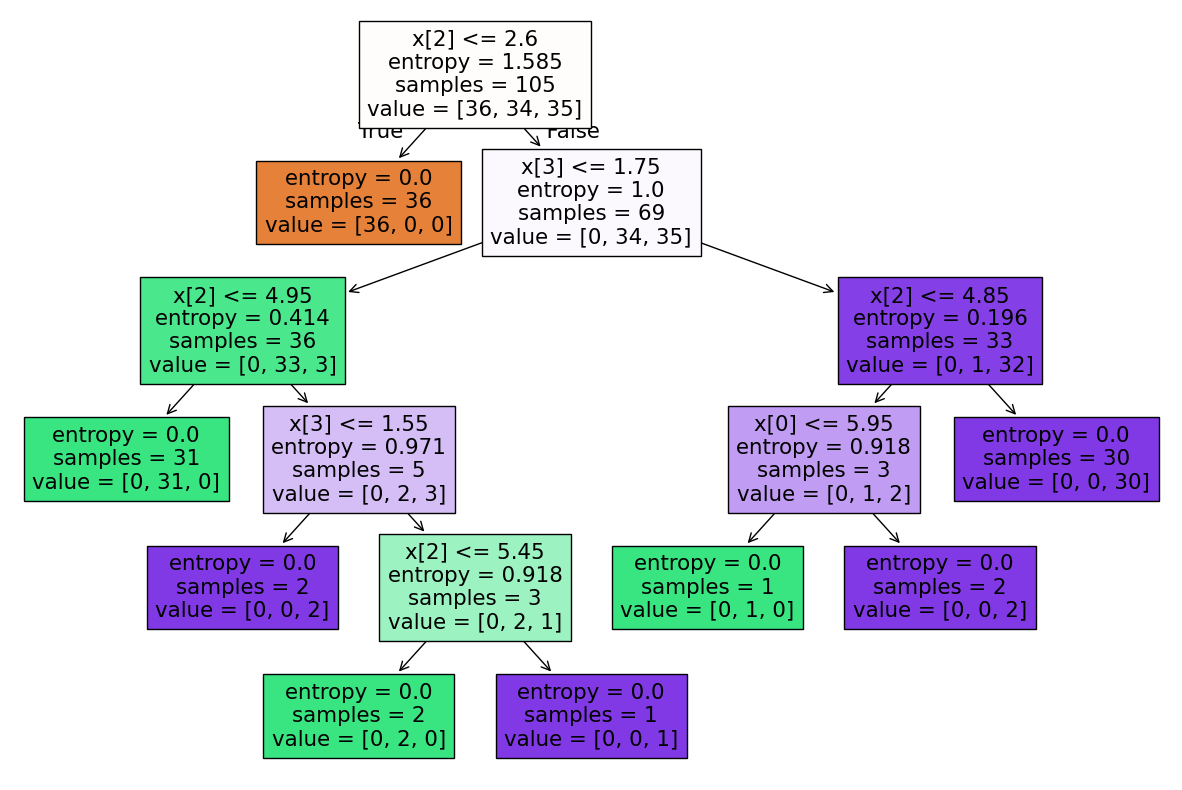

In [51]:
#get the visuals of the tree
from sklearn import tree
plt.figure(
    figsize =(15,10))
tree.plot_tree(model,filled= True)
plt.show()

In [52]:
#prediciton stage
y_pred = model.predict(x_test)

In [53]:
from sklearn.metrics import accuracy_score , classification_report
acc = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)
print( f"Accuracy : {acc}")
print( f"Classification Report : {cr}")


Accuracy : 0.9777777777777777
Classification Report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      1.00      0.97        16
           2       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



There are many leaf branches that could have been cut offed to reduce time 

1. usinf Post pruning 

In [54]:
#get the model
from sklearn.tree import DecisionTreeClassifier
#apply post pruning on the decision tree
model = DecisionTreeClassifier(max_depth= 2) 


In [55]:
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2)

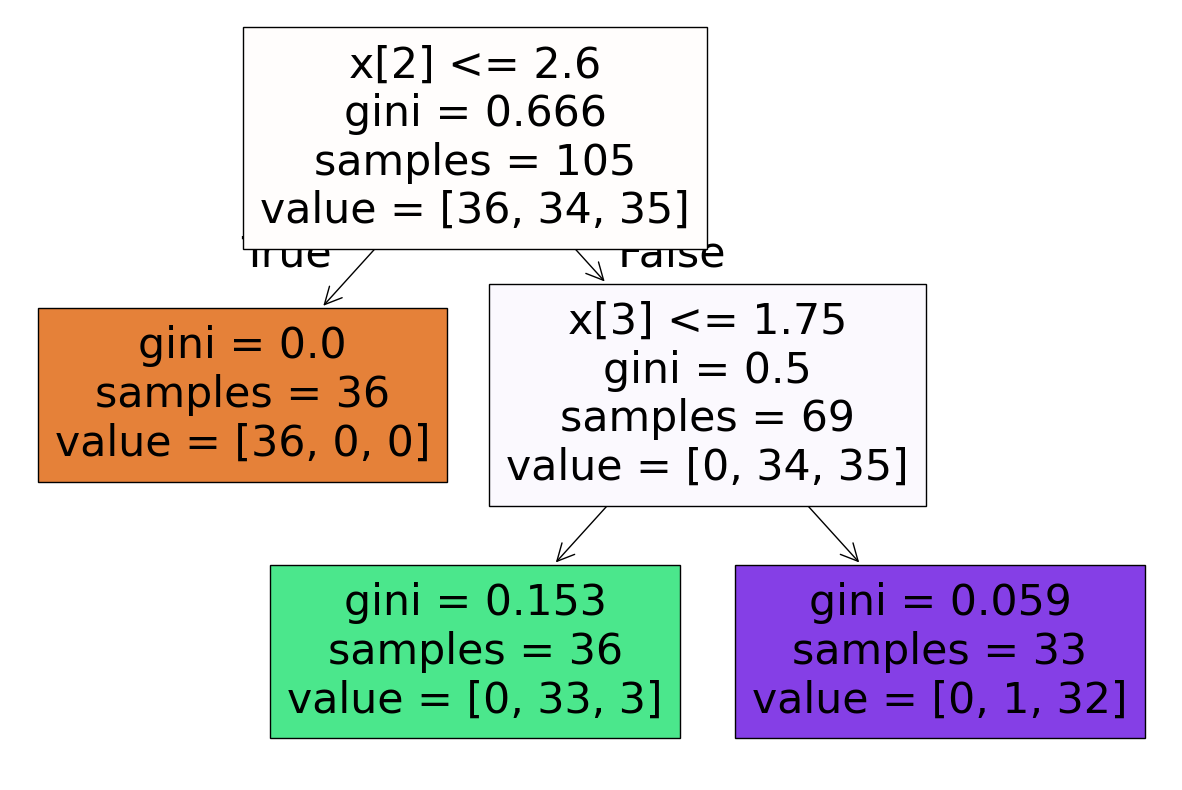

In [56]:
#get the visuals of the tree
from sklearn import tree
plt.figure(
    figsize =(15,10))
tree.plot_tree(model,filled= True)
plt.show()

In [57]:
#prediciton stage
y_pred = model.predict(x_test)

In [59]:
from sklearn.metrics import accuracy_score , classification_report
acc = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)
print( f"Accuracy : {acc}")
print( f"Classification Report : {cr}")


Accuracy : 0.9555555555555556
Classification Report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.89      1.00      0.94        16
           2       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



2. Applying Prepruning

In [75]:
#get all the parameters provided by the decision tree
parameter = {
    "criterion" :["gini", "entropy","log_loss"],
    "splitter" : ["best", "random"],
    "max_depth" : [1,2,3,4,5],
    "max_features" : ["sqrt","log2",None]
    # "ccp_alpha" : [1,2,3,4,5,6,7]
}


In [76]:
#importing gsv as 
from sklearn.model_selection import GridSearchCV

In [77]:
treemodel = DecisionTreeClassifier()
gridmodel = GridSearchCV(treemodel,param_grid=parameter,cv = 5,scoring = "accuracy")

In [78]:
#data training
gridmodel.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [79]:
# get the best possible parameters for working
gridmodel.best_params_

{'criterion': 'log_loss',
 'max_depth': 4,
 'max_features': None,
 'splitter': 'best'}

In [82]:
y_pred = gridmodel.predict(x_test)
y_pred

array([0, 0, 2, 1, 0, 0, 2, 0, 2, 2, 1, 0, 2, 1, 1, 1, 2, 2, 2, 0, 2, 0,
       0, 1, 1, 0, 1, 1, 2, 1, 1, 0, 2, 1, 1, 0, 2, 1, 2, 1, 0, 0, 2, 1,
       1])

In [84]:
from sklearn.metrics import accuracy_score,classification_report
acc = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)
print( f"Accuracy : {acc}")
print( f"Classification Report :\n {cr}")

Accuracy : 0.9777777777777777
Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      1.00      0.97        16
           2       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

